# Lab 8 - Segmentation

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, June 6th (23:59)**

------
**Objective:** In this lab you will go from raw images to pixel-precise segmentation masks.  
You will explore classical methods, use the Segment Anything Model (SAM ViT-B) with different prompt strategies, implement evaluation metrics from scratch, and interpret your results.

**Dataset:** Oxford-IIIT Pets (5-breed subset, 50 images)  
**Model:** SAM ViT-B (~375 MB) — the lightweight version of Meta's SAM

---
>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


---
## Part 0 — Installation and Setup
Run the cells below once. They install all required libraries and download the SAM ViT-B checkpoint.


In [1]:
# Install required libraries
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install opencv-python-headless matplotlib numpy torchvision tqdm -q
print("✅ Libraries installed")


✅ Libraries installed


In [4]:
import os

# Download SAM ViT-B checkpoint (~375 MB)
checkpoint_path = "sam_vit_b_01ec64.pth"
if not os.path.exists(checkpoint_path):
    print("Downloading SAM ViT-B checkpoint (~375 MB) ...")
    # !wget -q --show-progress https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    !curl -O https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("✅ Checkpoint downloaded")
else:
    print("✅ Checkpoint already exists")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  357M  100  357M    0     0  10.9M      0  0:00:32  0:00:32 --:--:-- 10.6M  0:00:33  0:00:10  0:00:23 10.7M  10.9M      0  0:00:32  0:00:20  0:00:12 10.9M
✅ Checkpoint downloaded


In [9]:
# Download Oxford-IIIT Pets dataset (images + annotations)
import os

!rm -f images.tar.gz annotations.tar.gz

if not os.path.exists("oxford-iiit-pet"):
    os.makedirs("oxford-iiit-pet", exist_ok=True)
    print("Downloading Oxford-IIIT Pets images ...")
    # !wget -q --show-progress https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
    # !wget -q --show-progress https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
    !curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
    !curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
    !tar -xzf images.tar.gz -C oxford-iiit-pet/
    !tar -xzf annotations.tar.gz -C oxford-iiit-pet/
    print("✅ Dataset downloaded and extracted")
else:
    print("✅ Dataset already exists")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   340  100   340    0     0   3833      0 --:--:-- --:--:-- --:--:--  3863
100  755M  100  755M    0     0  9933k      0  0:01:17  0:01:17 --:--:-- 10.5M   9.8M      0  0:01:16  0:00:06  0:01:10 10.2M      0  0:01:15  0:00:14  0:01:01 10.2M1M      0  0:01:14  0:00:51  0:00:23 10.2M67k   0  0:01:18  0:01:11  0:00:07 5203k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   345  100   345    0     0   3559      0 --:--:-- --:--:-- --:--:--  3593
100 18.2M  100 18.2M    0     0  8646k      0  0:00:02  0:00:02 --:--:-- 9833k
✅ Dataset downloaded and extracted


In [10]:
# Global imports — run this cell before anything else
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
import os
import random
from pathlib import Path
from PIL import Image

# SAM imports
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

# Reproducibility
random.seed(42)
np.random.seed(42)

print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


✅ All imports successful
PyTorch version: 2.10.0
Device: cpu


---
## Part 1 — Data Exploration

Before building any model, we need to understand our data.  
The Oxford-IIIT Pets dataset contains images of cats and dogs with **trimap masks**.

A trimap has three pixel values:
- `1` → foreground (the pet)
- `2` → background
- `3` → boundary / uncertain region

We will work with a **5-breed subset** of 50 images for speed.


In [15]:
# ── Helper: load dataset paths (5 breeds, 10 images each) ──────────────────
BREEDS = ["Abyssinian", "Bengal", "Bombay", "british_shorthair", "german_shorthaired"]
IMG_DIR  = Path("oxford-iiit-pet/images")
MASK_DIR = Path("oxford-iiit-pet/annotations/trimaps")

def load_dataset(breeds=BREEDS, n_per_breed=10):
    """Return list of (image_path, mask_path) tuples for selected breeds."""
    pairs = []
    for breed in breeds:
        imgs = sorted(IMG_DIR.glob(f"{breed}_*.jpg"))[:n_per_breed]
        for img_path in imgs:
            mask_path = MASK_DIR / (img_path.stem + ".png")
            if mask_path.exists():
                pairs.append((img_path, mask_path))
            
        print(f"Loaded {len(imgs[:n_per_breed])} pairs for breed '{breed}'")
    random.shuffle(pairs)
    return pairs

dataset = load_dataset()
print(f"✅ Dataset loaded: {len(dataset)} image-mask pairs")


Loaded 10 pairs for breed 'Abyssinian'
Loaded 10 pairs for breed 'Bengal'
Loaded 10 pairs for breed 'Bombay'
Loaded 0 pairs for breed 'british_shorthair'
Loaded 10 pairs for breed 'german_shorthaired'
✅ Dataset loaded: 40 image-mask pairs


In [16]:
# ── Helper: load image and mask ─────────────────────────────────────────────
def load_image(path):
    """Load image as RGB numpy array."""
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_mask(path):
    """Load trimap mask as numpy array (values: 1, 2, 3)."""
    return np.array(Image.open(path))

# Quick sanity check
img, mask = load_image(dataset[0][0]), load_mask(dataset[0][1])
print(f"Image shape : {img.shape}  dtype: {img.dtype}")
print(f"Mask shape  : {mask.shape}  unique values: {np.unique(mask)}")


Image shape : (500, 375, 3)  dtype: uint8
Mask shape  : (500, 375)  unique values: [1 2 3]


### TODO 1 — Visualize 5 images with their ground truth masks
Complete the function below to display 5 random image-mask pairs side by side.  
Each row should show: **original image | trimap mask | colored overlay**.

**Hint:** use `plt.imshow()`. For the overlay, you can use a colormap like `'jet'` on the mask.


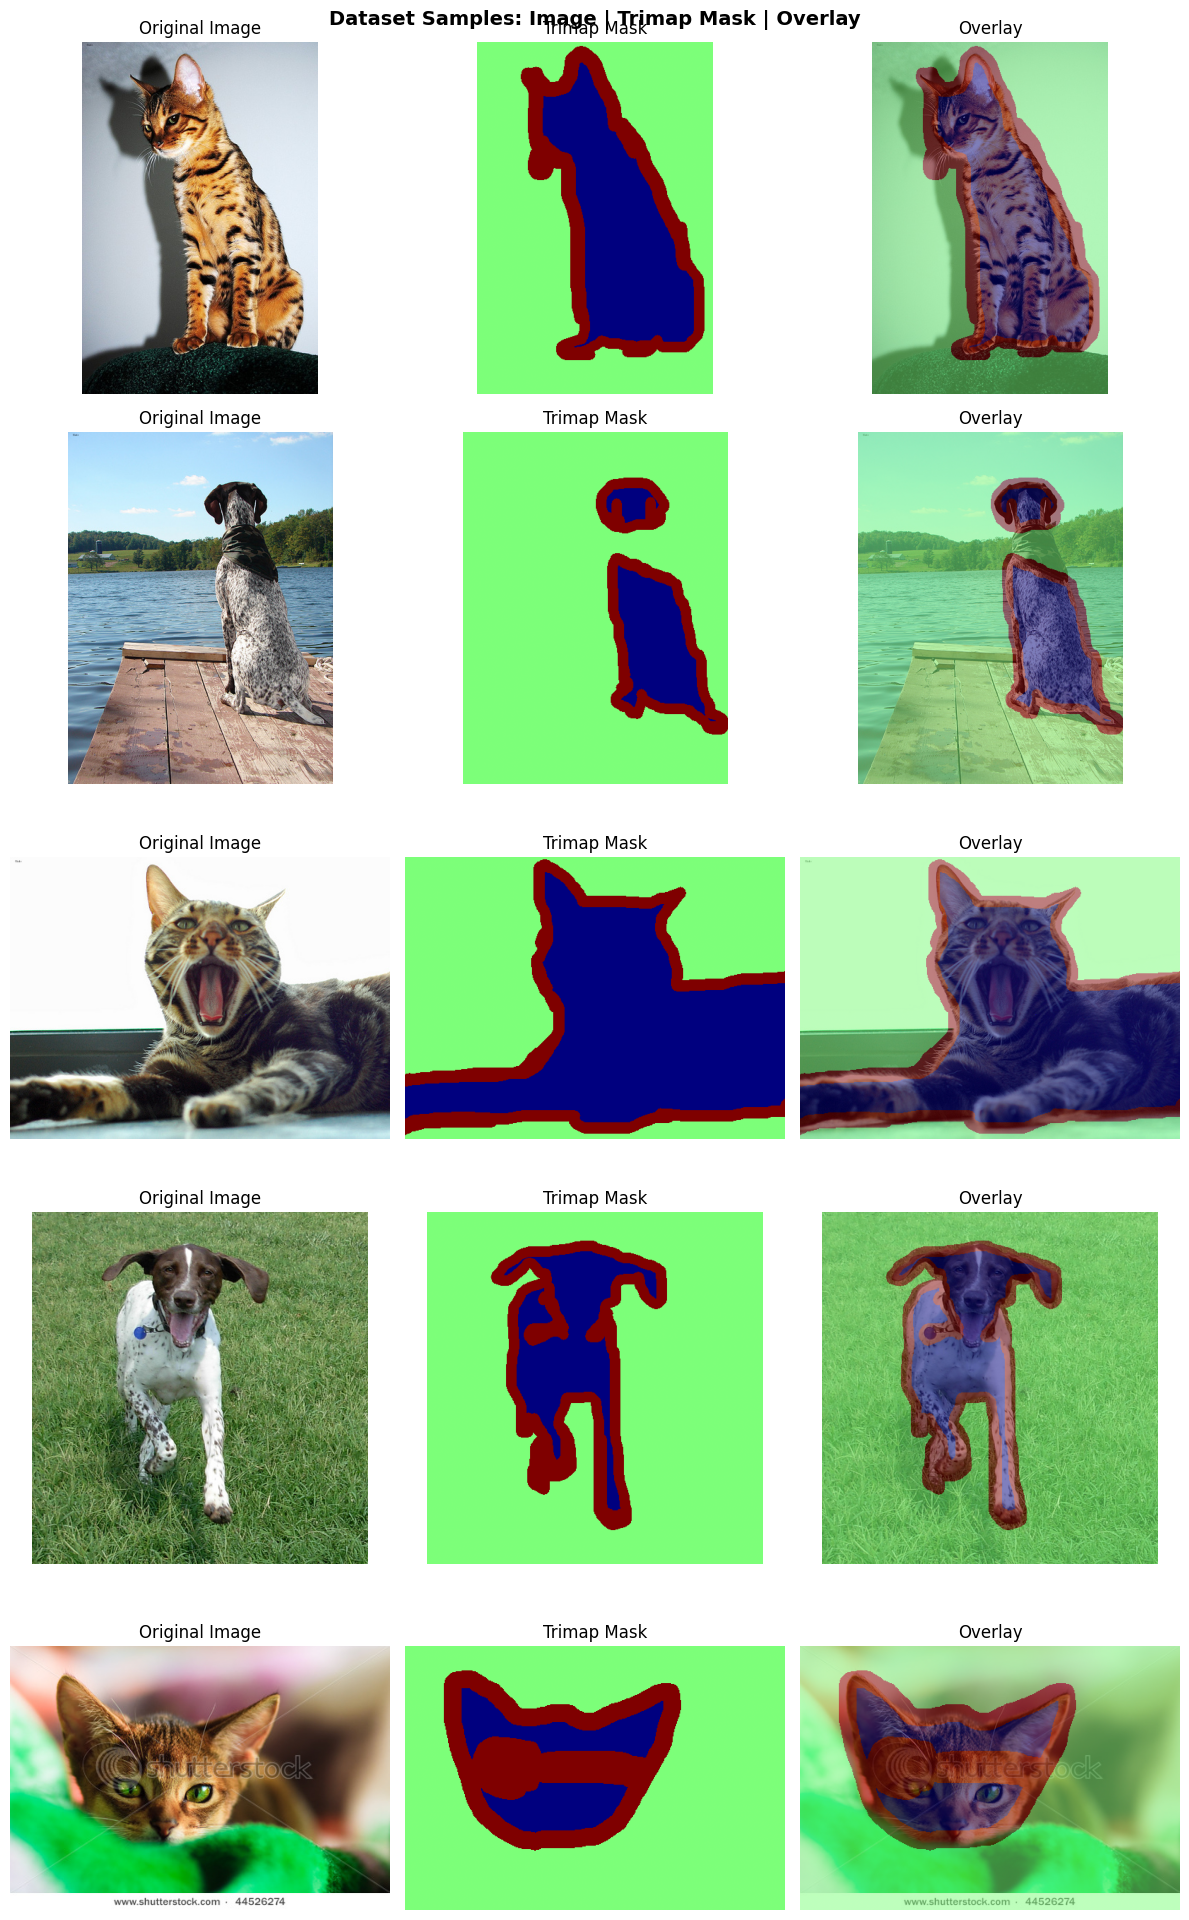

In [24]:
def visualize_samples(dataset, n=5):
    """
    Display n samples from the dataset.
    Each row: original image | trimap mask | overlay
    """
    samples = random.sample(dataset, n)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle("Dataset Samples: Image | Trimap Mask | Overlay", fontsize=14, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img  = load_image(img_path)
        mask = load_mask(mask_path)

        # ── TODO 1 ──────────────────────────────────────────────────────────
        # Display the original image in axes[i, 0]
        # Display the trimap mask in axes[i, 1] with colormap 'jet'
        # Display a semi-transparent mask overlay on the image in axes[i, 2]
        # Add a title to each column
        # ────────────────────────────────────────────────────────────────────
        axes[i,0].imshow(img)
        axes[i,0].set_title("Original Image")
        axes[i,0].axis('off')
        axes[i,1].imshow(mask, cmap='jet', vmin=1, vmax=3)
        axes[i,1].set_title("Trimap Mask")
        axes[i,1].axis('off')
        axes[i,2].imshow(img)
        axes[i,2].imshow(mask, cmap='jet', alpha=0.5, vmin=1, vmax=3)
        axes[i,2].set_title("Overlay")
        axes[i,2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(dataset, n=5)


### TODO 2 — Convert trimap to binary mask
The trimap has values 1 (pet), 2 (background), 3 (boundary).  
Convert it to a **binary mask**: `1` where the pixel is pet, `0` everywhere else.  
Treat boundary pixels (value 3) as foreground.


In [25]:
def trimap_to_binary(trimap):
    """
    Convert trimap mask to binary foreground mask.
    Args:
        trimap: numpy array with values 1 (pet), 2 (background), 3 (boundary)
    Returns:
        binary mask: numpy array with values 0 and 1
    """
    # ── TODO 2 ──────────────────────────────────────────────────────────────
    # Hint: use numpy boolean operations
    # raise NotImplementedError("TODO 2: implement trimap_to_binary")
    # ────────────────────────────────────────────────────────────────────────
    binary_mask = np.where((trimap == 1) | (trimap == 3), 1, 0)
    return binary_mask

# Test
sample_mask = load_mask(dataset[0][1])
binary = trimap_to_binary(sample_mask)
print(f"Trimap unique values : {np.unique(sample_mask)}")
print(f"Binary unique values : {np.unique(binary)}")
print(f"Foreground pixels    : {binary.sum()} / {binary.size} ({100*binary.mean():.1f}%)")


Trimap unique values : [1 2 3]
Binary unique values : [0 1]
Foreground pixels    : 33227 / 187500 (17.7%)


### TODO 3 — Plot foreground pixel distribution
For each of the 50 images, compute the percentage of foreground pixels.  
Plot a **bar chart** showing this distribution across all images.  
Add a horizontal line showing the mean foreground percentage.


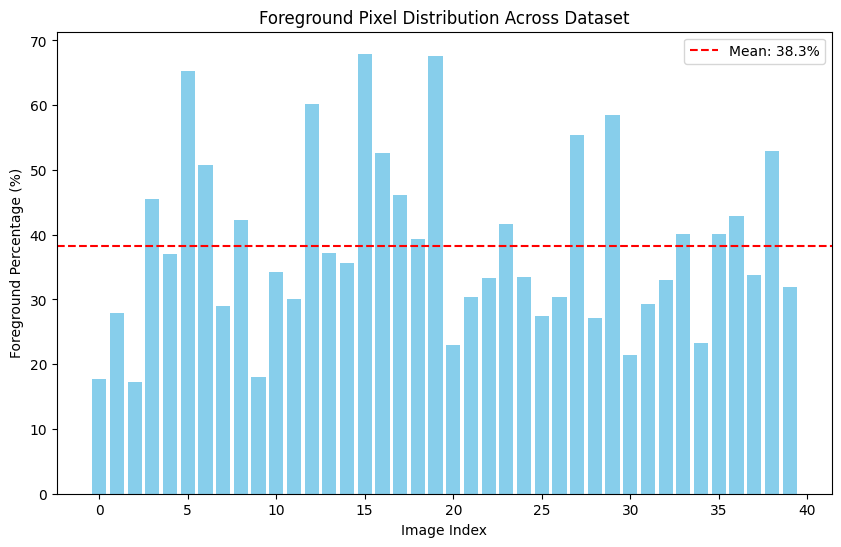

In [28]:
def plot_foreground_distribution(dataset):
    """
    For each image compute % of foreground pixels and plot as bar chart.
    """
    # ── TODO 3 ──────────────────────────────────────────────────────────────
    # 1. Loop over dataset, load each mask, convert to binary, compute fg %
    # 2. Store percentages in a list
    # 3. Add a red horizontal dashed line for the mean
    # raise NotImplementedError("TODO 3: implement plot_foreground_distribution")
    # ────────────────────────────────────────────────────────────────────────
    percentages = []
    for img_path, mask_path in dataset:
        mask = load_mask(mask_path)
        binary_mask = trimap_to_binary(mask)
        fg_percentage = 100 * binary_mask.mean()
        percentages.append(fg_percentage)
        
    mean_percentage = np.mean(percentages)
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(percentages)), percentages, color='skyblue')
    plt.axhline(mean_percentage, color='red', linestyle='--', label=f'Mean: {mean_percentage:.1f}%')
    plt.xlabel('Image Index')
    plt.ylabel('Foreground Percentage (%)')
    plt.title('Foreground Pixel Distribution Across Dataset')
    plt.legend()
    plt.show()

plot_foreground_distribution(dataset)


---
## Part 2 — Classical Segmentation: Why Naive Methods Fail

Before using SAM, we try two classical segmentation approaches:
- **Color thresholding** in HSV colorspace
- **Otsu's automatic thresholding** on grayscale

These methods require no learning, no data
But they have fundamental limitations, you will measure exactly how limited they are.


### TODO 4 — Color thresholding in HSV
Convert the image to HSV and threshold on the **saturation channel** to isolate the pet.  
Pets typically have higher saturation than backgrounds like grass or walls.


In [29]:
def color_threshold_segment(image_rgb):
    """
    Segment foreground using HSV saturation thresholding.
    Args:
        image_rgb: numpy array (H, W, 3) in RGB
    Returns:
        binary mask: numpy array (H, W) with values 0 and 1
    """
    # ── TODO 4 ──────────────────────────────────────────────────────────────
    # 1. Convert RGB image to HSV using cv2.cvtColor
    # 2. Extract the saturation channel (index 1)
    # 3. Apply a threshold: pixels with saturation > 60 are foreground
    # 4. Return binary mask (0 or 1, not 0 or 255)
    # raise NotImplementedError("TODO 4: implement color_threshold_segment")
    # ────────────────────────────────────────────────────────────────────────
    cvt_images = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    saturation = cvt_images[:, :, 1]
    binary_mask = np.where(saturation > 60, 1, 0)
    return binary_mask

# Test on one image
test_img = load_image(dataset[0][0])
pred = color_threshold_segment(test_img)
print(f"Predicted mask shape: {pred.shape}, unique: {np.unique(pred)}")


Predicted mask shape: (500, 375), unique: [0 1]


### TODO 5 — Morphological cleaning
Raw thresholding produces noisy masks with holes and isolated pixels.  
Apply **erosion followed by dilation** (opening) to clean the mask.


In [30]:
def morphological_clean(binary_mask, kernel_size=5, iterations=2):
    """
    Clean a binary mask using morphological opening (erosion then dilation).
    Args:
        binary_mask : numpy array (H, W) with values 0 and 1
        kernel_size : size of the structuring element
        iterations  : number of times to apply each operation
    Returns:
        cleaned binary mask
    """
    # ── TODO 5 ──────────────────────────────────────────────────────────────
    # 1. Create a kernel using cv2.getStructuringElement
    # 2. Convert mask to uint8 (multiply by 255)
    # 3. Apply cv2.erode() then cv2.dilate() with the kernel
    # 4. Convert back to binary (0 or 1) and return
    # raise NotImplementedError("TODO 5: implement morphological_clean")
    # ────────────────────────────────────────────────────────────────────────
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    mask_uint8 = (binary_mask * 255).astype(np.uint8)
    eroded = cv2.erode(mask_uint8, kernel, iterations=iterations)
    dilated = cv2.dilate(eroded, kernel, iterations=iterations)
    cleaned_mask = np.where(dilated > 0, 1, 0)
    return cleaned_mask

# Test on one image
test_img = load_image(dataset[0][0])
cleaned_pred = morphological_clean(pred)
print(f"Cleaned mask shape: {cleaned_pred.shape}, unique: {np.unique(cleaned_pred)}")

Cleaned mask shape: (500, 375), unique: [0 1]


### TODO 6 — Visualize thresholding results
Show 3 images with: **original | predicted mask | colored overlay on image**.


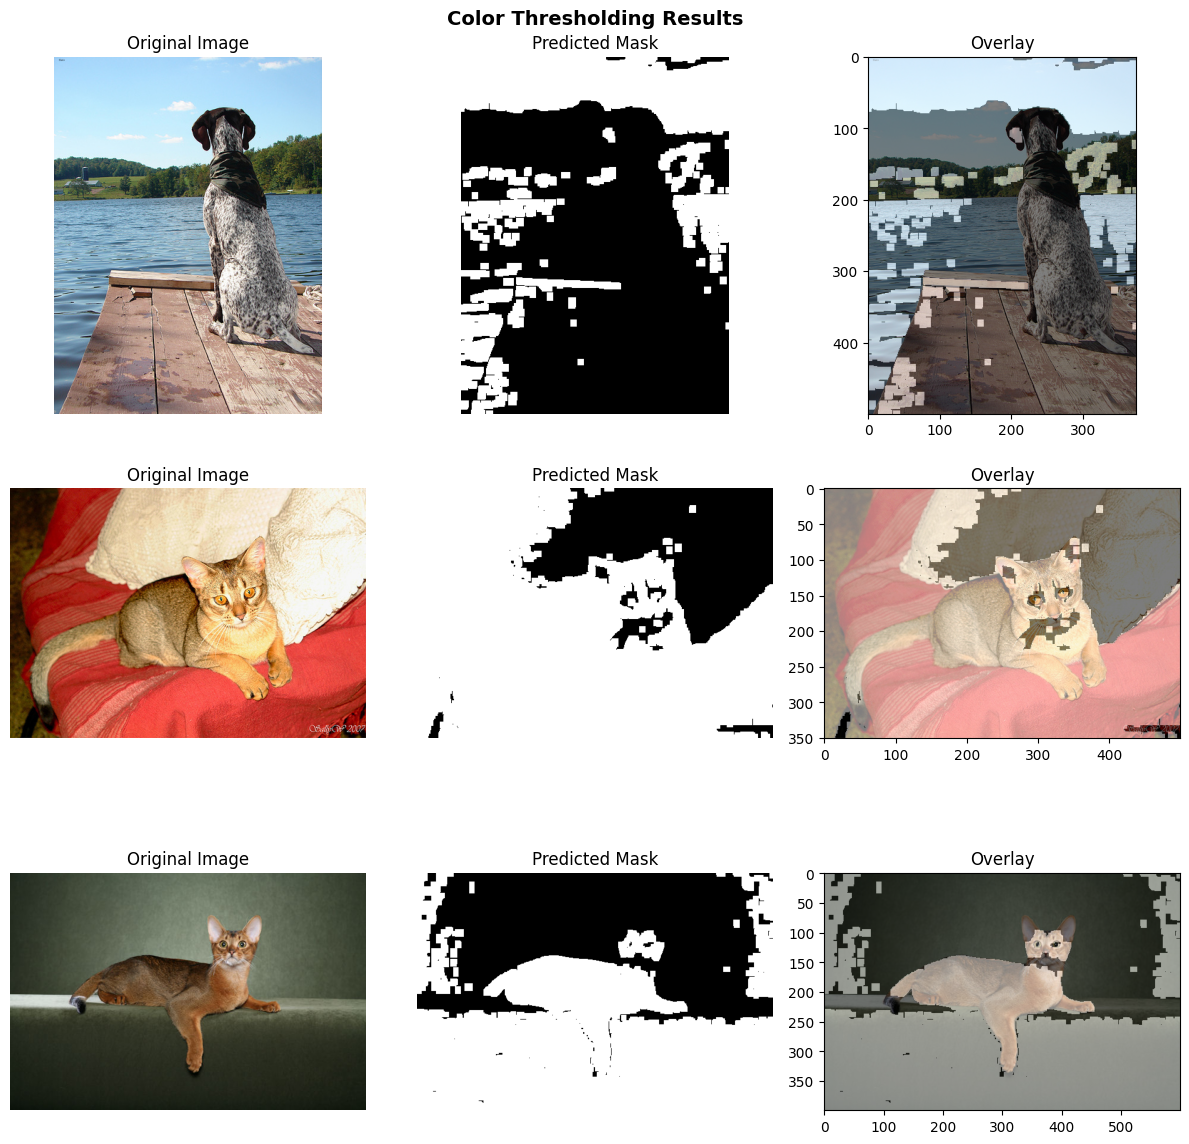

In [33]:
def visualize_classical(dataset, segment_fn, clean_fn, title, n=3):
    """
    Visualize classical segmentation results.
    Each row: original image | predicted mask | overlay
    """
    samples = dataset[:n]
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img    = load_image(img_path)
        gt     = trimap_to_binary(load_mask(mask_path))
        pred   = clean_fn(segment_fn(img))

        # ── TODO 6 ──────────────────────────────────────────────────────────
        # Display: original image | predicted mask | overlay
        # Title each column: "Original", "Predicted Mask", "Overlay"
        # For the overlay: show image with semi-transparent mask on top
        # raise NotImplementedError("TODO 6: implement visualization")
        # ────────────────────────────────────────────────────────────────────

        axes[i,0].imshow(img)
        axes[i,0].set_title("Original Image")
        axes[i,0].axis('off')
        axes[i,1].imshow(pred, cmap='gray')
        axes[i,1].set_title("Predicted Mask")
        axes[i,1].axis('off')
        axes[i,2].imshow(img)
        axes[i,2].imshow(pred, cmap='gray', alpha=0.5)
        axes[i,2].set_title("Overlay")
        
    plt.tight_layout()
    plt.show()

visualize_classical(dataset, color_threshold_segment, morphological_clean, "Color Thresholding Results", n=3)


### TODO 7 — Otsu's automatic thresholding
Otsu's method automatically finds the optimal threshold on the **grayscale** image.  
It requires no manual parameter tuning.


In [34]:
def otsu_segment(image_rgb):
    """
    Segment foreground using Otsu's automatic thresholding on grayscale.
    Args:
        image_rgb: numpy array (H, W, 3) in RGB
    Returns:
        binary mask: numpy array (H, W) with values 0 and 1
    """
    # ── TODO 7 ──────────────────────────────────────────────────────────────
    # 1. Convert RGB to grayscale using cv2.cvtColor
    # 2. Apply Otsu thresholding: cv2.threshold with cv2.THRESH_OTSU flag
    # 3. Return binary mask (0 or 1)
    # raise NotImplementedError("TODO 7: implement otsu_segment")
    # ────────────────────────────────────────────────────────────────────────
    cvt_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, binary_mask = cv2.threshold(cvt_image, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary_mask


### TODO 8 — Compare methods side by side
Display 5 images as a grid: **original | color threshold | Otsu | ground truth**  
4 columns, 5 rows.


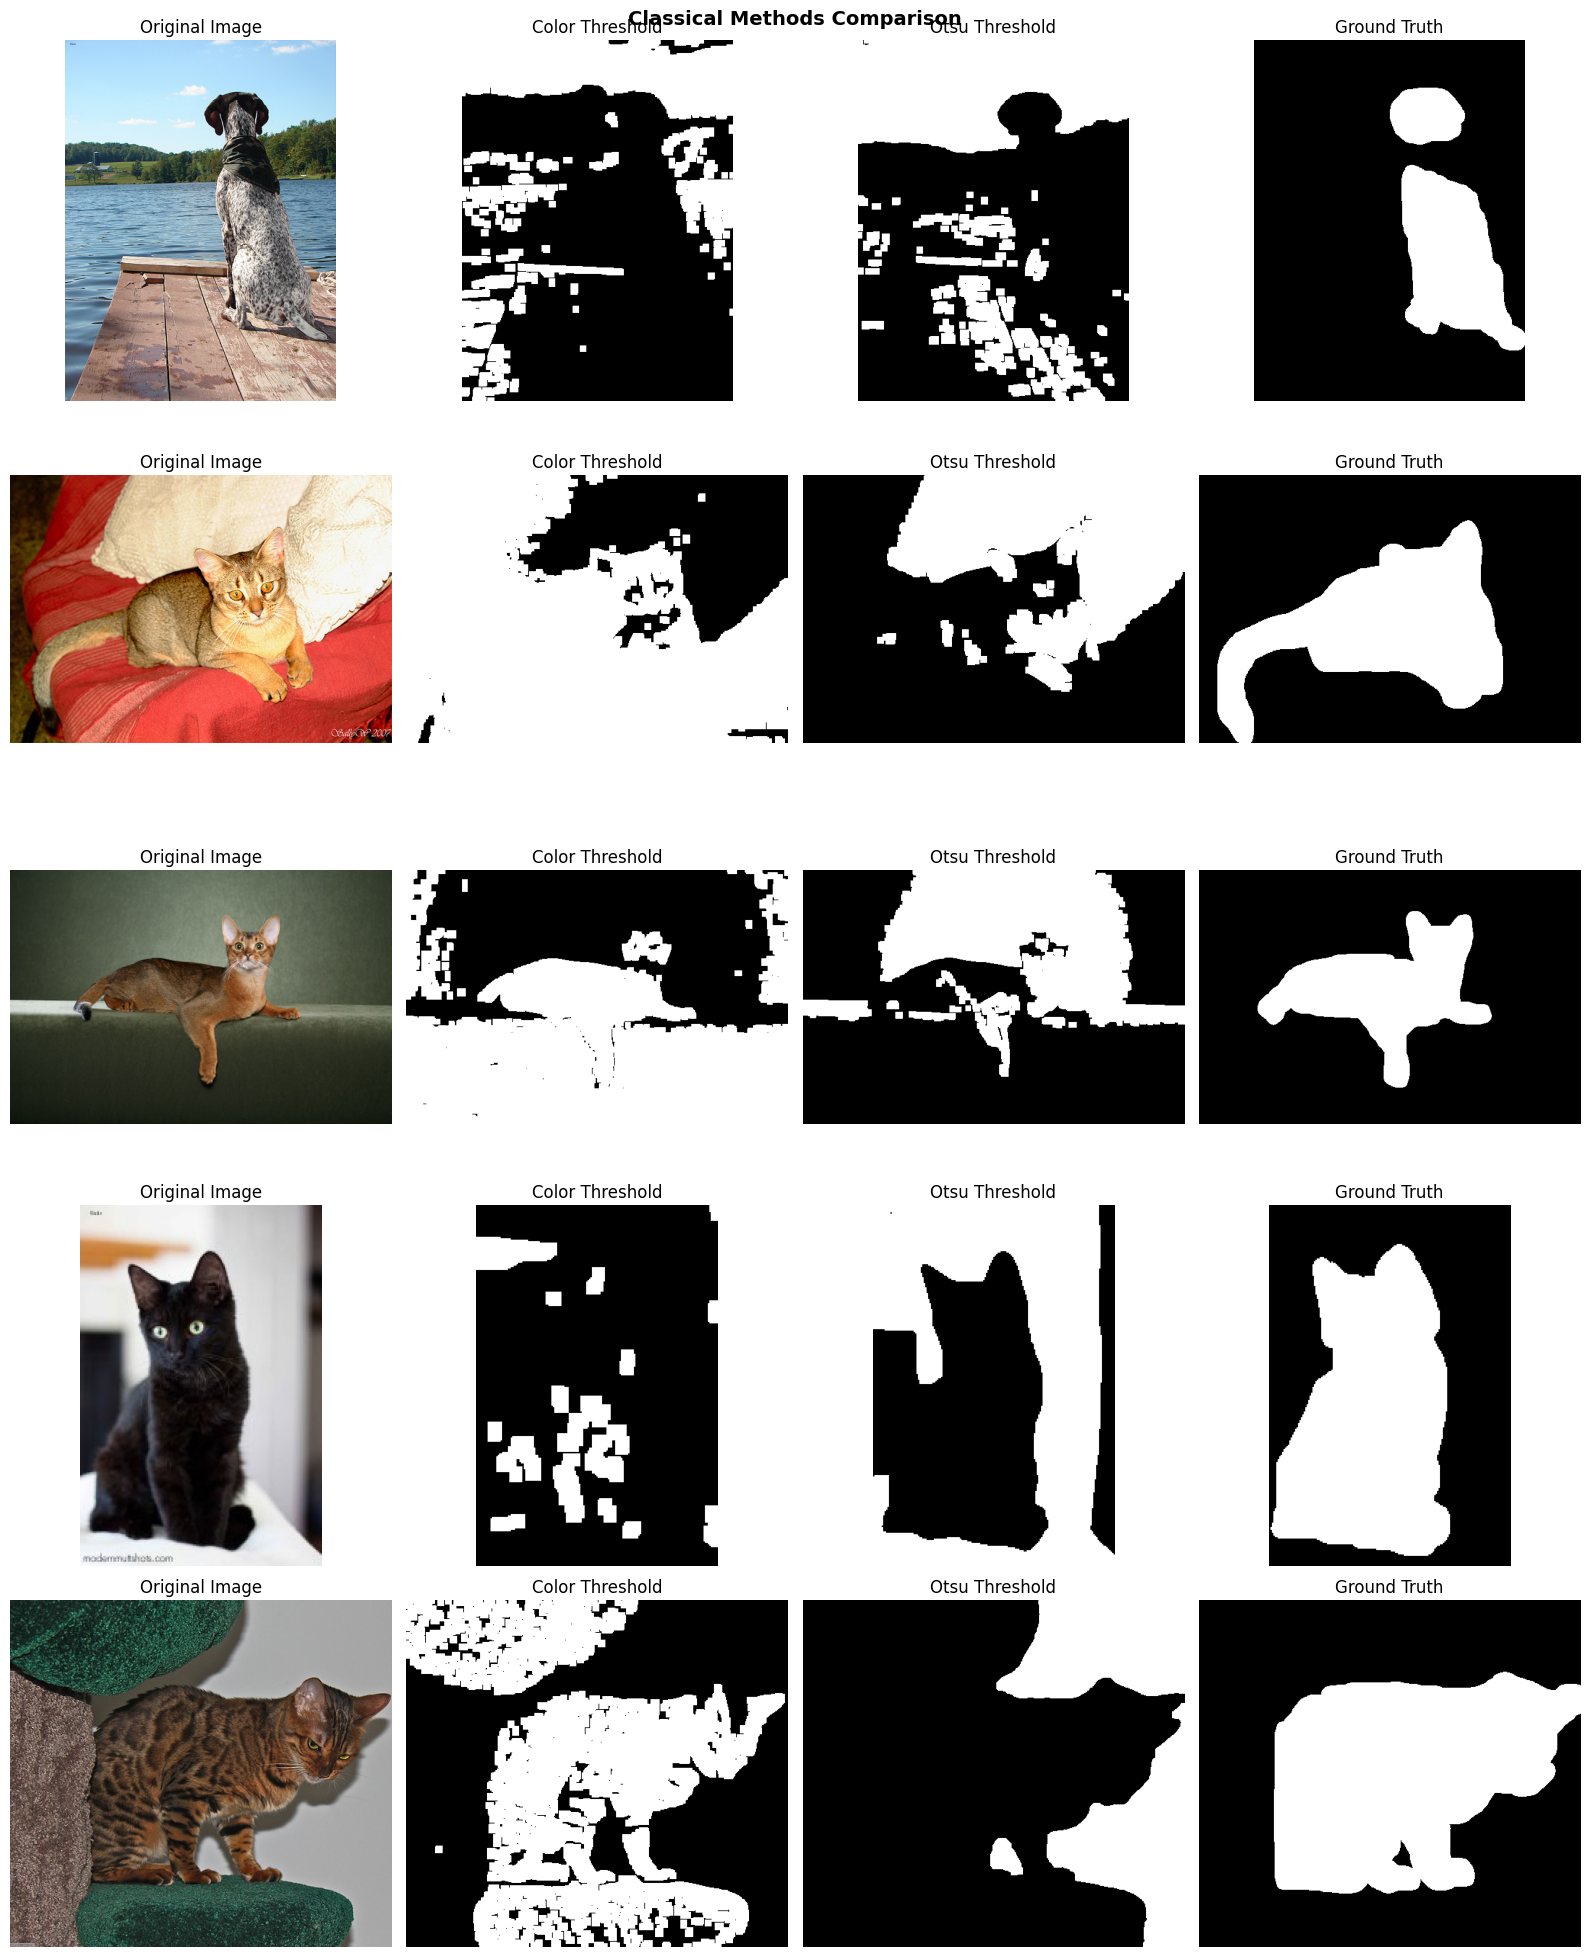

In [35]:
def compare_classical_methods(dataset, n=5):
    """
    Compare color thresholding vs Otsu vs ground truth.
    Grid: n rows x 4 columns (original, color thresh, otsu, ground truth)
    """
    samples = dataset[:n]
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    fig.suptitle("Classical Methods Comparison", fontsize=14, fontweight='bold')
    col_titles = ["Original", "Color Threshold", "Otsu", "Ground Truth"]

    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img    = load_image(img_path)
        gt     = trimap_to_binary(load_mask(mask_path))
        color  = morphological_clean(color_threshold_segment(img))
        otsu   = morphological_clean(otsu_segment(img))

        # ── TODO 8 ──────────────────────────────────────────────────────────
        # Display: original | color threshold mask | otsu mask | ground truth
        # Use cmap='gray' for masks
        # Turn off axes ticks for all subplots
        # raise NotImplementedError("TODO 8: implement comparison grid")
        # ────────────────────────────────────────────────────────────────────
        axes[i,0].imshow(img)
        axes[i,0].set_title("Original Image")
        axes[i,0].axis('off')
        axes[i,1].imshow(color, cmap='gray')
        axes[i,1].set_title("Color Threshold")
        axes[i,1].axis('off')
        axes[i,2].imshow(otsu, cmap='gray')
        axes[i,2].set_title("Otsu Threshold")
        axes[i,2].axis('off')
        axes[i,3].imshow(gt, cmap='gray')
        axes[i,3].set_title("Ground Truth")
        axes[i,3].axis('off')   
        
    plt.tight_layout()
    plt.show()

compare_classical_methods(dataset, n=5)


---
## Part 3 — SAM ViT-B

We now move to the Segment Anything Model. SAM takes an image and a **prompt** as input and returns a precise mask.

Three prompt strategies, three exercises:
- **3A** — Point prompt: click on the object
- **3B** — Box prompt: draw a bounding box around the object
- **3C** — Automatic: no prompt at all — SAM segments everything


In [36]:
# ── Load SAM ViT-B ───────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = "sam_vit_b_01ec64.pth"

sam = sam_model_registry["vit_b"](checkpoint=CHECKPOINT)
sam.eval()
sam.to(DEVICE)

predictor = SamPredictor(sam)
print(f"✅ SAM ViT-B loaded on {DEVICE}")


✅ SAM ViT-B loaded on cpu


### Exercise 3A — Point Prompt
**The idea:** you click one point on the pet. SAM returns three candidate masks ranked by confidence.  
You then pick the best one.


#### TODO 9 — Encode the image into SAM's embedding
Call `predictor.set_image()` to compute the image embedding.  
This is the expensive step — it runs the ViT-B encoder once per image.


In [38]:
# Load a test image for Part 3
test_img_path, test_mask_path = dataset[0]
test_img  = load_image(test_img_path)
test_gt   = trimap_to_binary(load_mask(test_mask_path))

print(f"Image: {test_img_path.name}  shape: {test_img.shape}")

# ── TODO 9 ──────────────────────────────────────────────────────────────────
# Call predictor.set_image() with test_img
# Note: SAM expects a numpy array in RGB format — which is what load_image returns
# raise NotImplementedError("TODO 9: call predictor.set_image()")
# ────────────────────────────────────────────────────────────────────────────
test_enc = predictor.set_image(test_img)
print("✅ Image encoded")


Image: german_shorthaired_1.jpg  shape: (500, 375, 3)
✅ Image encoded


#### TODO 10 — Define a point prompt
Define a single foreground point at the **center of the image**.  
SAM expects points as numpy arrays of shape `(N, 2)` and labels as `(N,)`.  
Label `1` = foreground, `0` = background.


In [40]:
# ── TODO 10 ─────────────────────────────────────────────────────────────────
# Define:
#   point_coords: numpy array shape (1, 2) with [x, y] at image center
#   point_labels: numpy array shape (1,) with value 1 (foreground)
# Hint: image center is at (width//2, height//2)
#       image shape is (H, W, C) so width = test_img.shape[1], height = test_img.shape[0]

# raise NotImplementedError("TODO 10: define point_coords and point_labels")
# ────────────────────────────────────────────────────────────────────────────
height, width = test_img.shape[0], test_img.shape[1]
point_coords = np.array([[width//2, height//2]])
point_labels = np.array([1])
print(f"Point coords : {point_coords}")
print(f"Point labels : {point_labels}")


Point coords : [[187 250]]
Point labels : [1]


#### TODO 11 — Run SAM prediction with point prompt
Call `predictor.predict()` with your point coordinates and labels.  
Collect the three output masks and their IoU scores.


In [43]:
# ── TODO 11 ─────────────────────────────────────────────────────────────────
# Call predictor.predict() with:
#   point_coords = point_coords
#   point_labels = point_labels
#   multimask_output = True  ← always True to get 3 masks
# The function returns: masks, scores, logits
# masks shape: (3, H, W) — three binary masks
# scores shape: (3,) — confidence score for each mask

# raise NotImplementedError("TODO 11: call predictor.predict() with point prompt")
# ────────────────────────────────────────────────────────────────────────────
res = predictor.predict(point_coords=point_coords, point_labels=point_labels, multimask_output=True)
masks, scores, logits = res[0], res[1], res[2]
print(f"Masks shape  : {masks.shape}")
print(f"IoU scores   : {scores.round(3)}")


Masks shape  : (3, 500, 375)
IoU scores   : [0.974 0.987 0.935]


#### TODO 12 — Visualize the three SAM masks
Display the three masks SAM returned, each with its confidence score as title.  
Use a colored semi-transparent overlay on the original image.


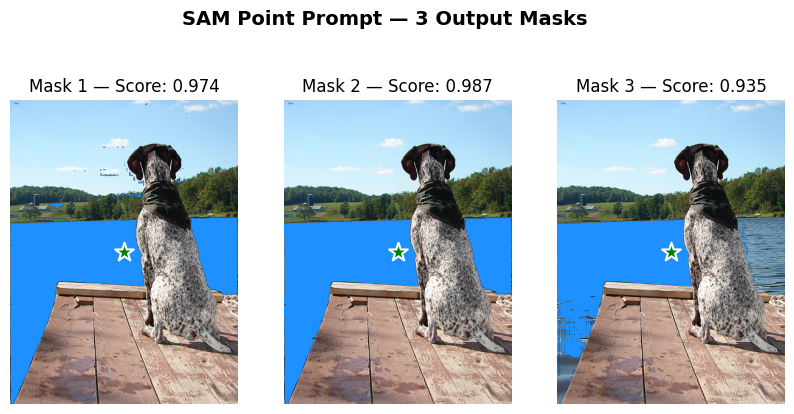

In [55]:
def show_mask(mask, ax, color=None, alpha=0.5):
    """Overlay a binary mask on an existing axes with a given color."""
    if color is None:
        color = np.array([30/255, 144/255, 255/255])
    h, w = mask.shape
    mask_img = np.zeros((h, w, 4))
    mask_img[mask == 1] = [*color, alpha]
    ax.imshow(mask_img)

def show_point(coords, labels, ax):
    """Draw prompt points on axes (green=fg, red=bg)."""
    for coord, label in zip(coords, labels):
        color = 'green' if label == 1 else 'red'
        ax.scatter(coord[0], coord[1], c=color, s=200, marker='*',
                   edgecolors='white', linewidths=1.5, zorder=5)

# ── TODO 12 ─────────────────────────────────────────────────────────────────
# Create a figure with 1 row and 3 columns
# For each of the 3 masks:
#   - Display test_img as background
#   - Call show_mask() to overlay the mask
#   - Call show_point() to show the prompt point
#   - Set title to f"Mask {i+1} — Score: {scores[i]:.3f}"
# Add a main title: "SAM Point Prompt — 3 Output Masks"

# raise NotImplementedError("TODO 12: visualize 3 SAM masks")
# ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle("SAM Point Prompt — 3 Output Masks", fontsize=14, fontweight='bold')
for i in range(3):
    axes[i].imshow(test_img)
    show_mask(masks[i], axes[i], alpha=1)
    show_point(point_coords, point_labels, axes[i])
    axes[i].set_title(f"Mask {i+1} — Score: {scores[i]:.3f}")
    axes[i].axis('off')
    


###  Reflection — Point Prompt
**Q: SAM returned three masks. Which one is best? Why did SAM return three instead of one?**

Mask 2 is the best (highest score: 0.987). The center point landed on a water/background region rather than the dog, so SAM segmented the water instead of the pet. SAM returns three masks because a single point is ambiguous, it could belong to a small, medium, or large region, so SAM proposes all three scales and lets the user pick the most relevant one.

---
### Exercise 3B — Box Prompt
**The idea:** instead of a point, we give SAM a bounding box around the pet.  
We compute this box automatically from the ground truth mask.


#### TODO 13 — Compute bounding box from ground truth mask
Find the tight bounding box around the foreground region of the binary mask.  
SAM expects boxes as `[x_min, y_min, x_max, y_max]`.


In [57]:
def mask_to_bbox(binary_mask):
    """
    Compute bounding box of foreground region in a binary mask.
    Args:
        binary_mask: numpy array (H, W) with values 0 and 1
    Returns:
        numpy array [x_min, y_min, x_max, y_max]
    """
    # ── TODO 13 ─────────────────────────────────────────────────────────────
    # Use np.where to find rows and columns where mask == 1
    # x_min = cols.min(), x_max = cols.max()
    # y_min = rows.min(), y_max = rows.max()
    # Return as numpy array: np.array([x_min, y_min, x_max, y_max])
    # raise NotImplementedError("TODO 13: implement mask_to_bbox")
    # ────────────────────────────────────────────────────────────────────────
    Y, X = np.where(binary_mask == 1)
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    return np.array([x_min, y_min, x_max, y_max])

# Test
bbox = mask_to_bbox(test_gt)
print(f"Bounding box: {bbox}")


Bounding box: [188  66 374 429]


#### TODO 14 — Run SAM with box prompt
Pass the bounding box to `predictor.predict()` using the `box` argument.


In [58]:
# ── TODO 14 ─────────────────────────────────────────────────────────────────
# Call predictor.predict() with:
#   box = bbox[None, :]   ← SAM expects shape (1, 4)
#   multimask_output = False  ← box prompts usually return 1 mask
# Collect masks, scores, logits

# raise NotImplementedError("TODO 14: call predictor.predict() with box prompt")
# ────────────────────────────────────────────────────────────────────────────
masks, scores, logits = predictor.predict(box=bbox[None, :], multimask_output=False)

box_mask = masks[0]
print(f"Box mask shape: {box_mask.shape}, score: {scores[0]:.3f}")


Box mask shape: (500, 375), score: 0.990


#### TODO 15 — Compare point vs box prompt vs ground truth
Display 3 images side by side: **point prompt result | box prompt result | ground truth**  
Do this for 3 different images from the dataset.


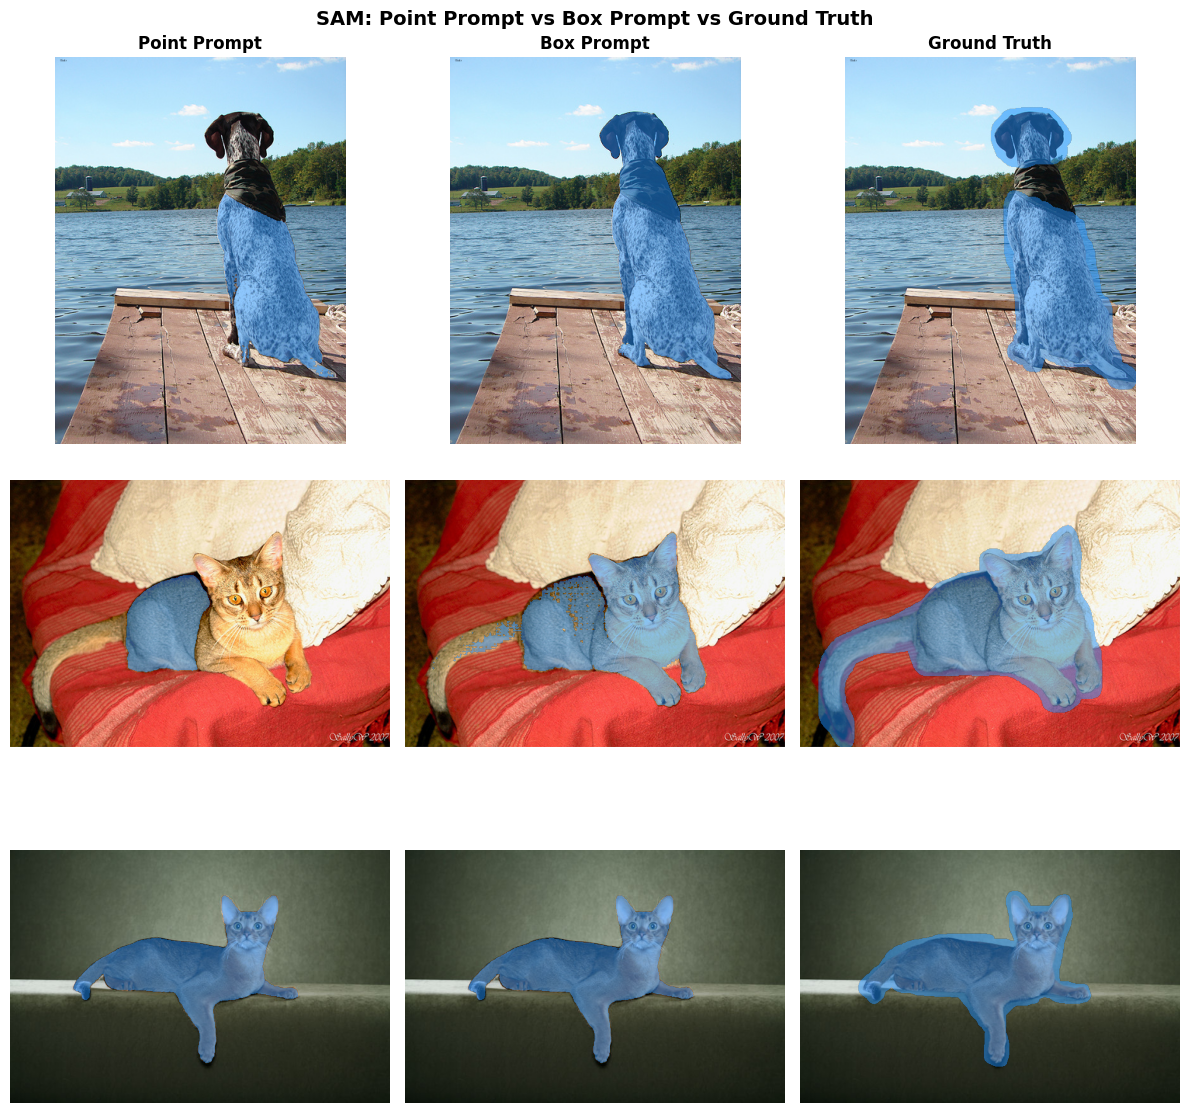

In [62]:
def compare_prompts(dataset, predictor, n=3):
    """
    Compare point prompt vs box prompt vs ground truth for n images.
    """
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle("SAM: Point Prompt vs Box Prompt vs Ground Truth",
                 fontsize=14, fontweight='bold')
    col_titles = ["Point Prompt", "Box Prompt", "Ground Truth"]
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t, fontsize=12, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(dataset[:n]):
        img = load_image(img_path)
        gt  = trimap_to_binary(load_mask(mask_path))
        box = mask_to_bbox(gt)

        # ── TODO 15 ──────────────────────────────────────────────────────────
        # 1. Call predictor.set_image(img)
        # 2. Get point prompt mask (center point, label 1, multimask_output=True, take mask[0])
        # 3. Get box prompt mask (box prompt, multimask_output=False, take mask[0])
        # 4. Display point mask | box mask | ground truth
        #    Use show_mask() helper for overlays
        # raise NotImplementedError("TODO 15: implement compare_prompts")
        # ─────────────────────────────────────────────────────────────────────
        predictor.set_image(img)
        
        point_coords = np.array([[box[0] + (box[2]-box[0])//2, box[1] + (box[3]-box[1])//2]])
        point_labels = np.array([1])
        res_point = predictor.predict(point_coords=point_coords, point_labels=point_labels, multimask_output=True)
        best_idx = np.argmax(res_point[1])  # scores are in res_point[1]
        point_mask = res_point[0][best_idx]
        
        res_box = predictor.predict(box=box[None, :], multimask_output=False)
        box_mask = res_box[0][0]
        
        # Point Prompt
        axes[i,0].imshow(img)                 
        show_mask(point_mask, axes[i,0])      
        axes[i,0].axis('off')
        
        # Box Prompt
        axes[i,1].imshow(img)
        show_mask(box_mask, axes[i,1])
        axes[i,1].axis('off')
        
        # Ground Truth
        axes[i,2].imshow(img)
        show_mask(gt, axes[i,2])
        axes[i,2].axis('off')

    plt.tight_layout()
    plt.show()

compare_prompts(dataset, predictor, n=3)


---
### Exercise 3C — Automatic Mask Generation
**The idea:** no prompt at all. SAM runs on a grid of points and segments everything it finds.


In [63]:
# ── Automatic mask generator — given, do not modify ────────────────────────
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=8,           # reduced for CPU speed
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=500,
)
print(" Automatic mask generator ready")


 Automatic mask generator ready


#### TODO 16 — Run automatic mask generation
Run the mask generator on one image and collect all detected masks.


In [64]:
auto_img_path, auto_mask_path = dataset[1]
auto_img = load_image(auto_img_path)

# ── TODO 16 ─────────────────────────────────────────────────────────────────
# Call mask_generator.generate(auto_img) and store the result in `auto_masks`
# raise NotImplementedError("TODO 16: call mask_generator.generate()")
# ────────────────────────────────────────────────────────────────────────────
auto_masks = mask_generator.generate(auto_img)
print(f"✅ Found {len(auto_masks)} masks automatically")
print(f"Keys in each mask dict: {list(auto_masks[0].keys())}")


✅ Found 10 masks automatically
Keys in each mask dict: ['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box']


#### TODO 17 — Visualize all automatic masks
Write a function that draws each mask with a different random color overlaid on the image.


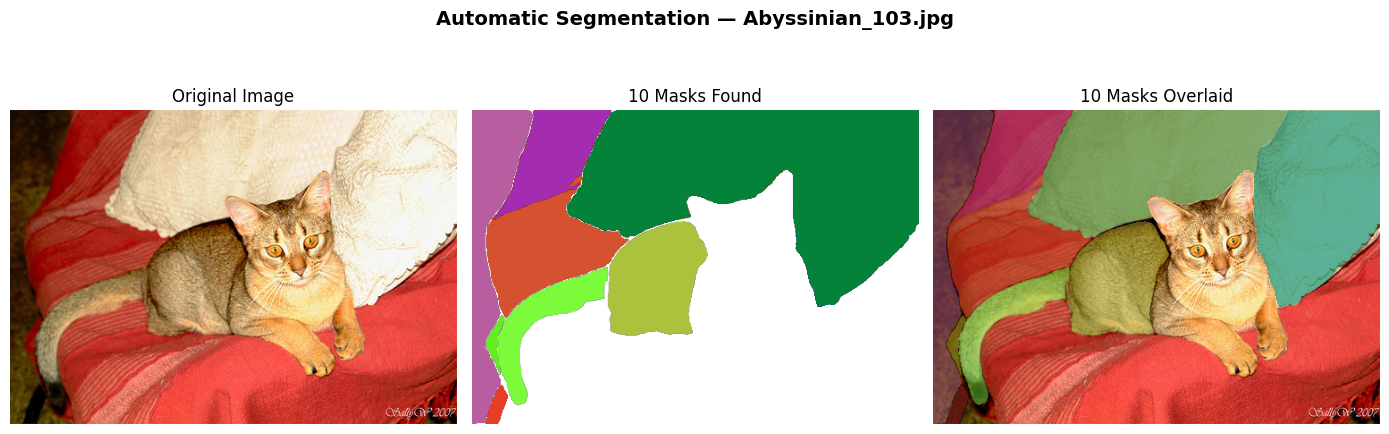

In [70]:
def show_all_masks(image, masks, title="Automatic Masks"):
    """
    Display image with all automatic masks overlaid, each with a different color.
    Args:
        image: RGB numpy array
        masks: list of mask dicts from SamAutomaticMaskGenerator
        title: plot title
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Left: original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Middle: image with all masks overlaid
    axes[1].set_title(f"{len(masks)} Masks Found")
    axes[1].axis('off')

    # Right: image with all masks overlaid
    axes[2].imshow(image)
    axes[2].set_title(f"{len(masks)} Masks Overlaid")
    axes[2].axis('off')

    # ── TODO 17 ─────────────────────────────────────────────────────────────
    # For each mask in masks:
    #   1. Generate a random RGB color: np.random.rand(3)
    #   2. Call show_mask(mask['segmentation'], axes[1], color=color, alpha=0.4)
    # Turn off axes[1] ticks
    # raise NotImplementedError("TODO 17: implement show_all_masks")
    # ────────────────────────────────────────────────────────────────────────
    for mask in masks:
        color = np.random.rand(3)
        show_mask(mask['segmentation'], axes[1], color=color, alpha=1)
        show_mask(mask['segmentation'], axes[2], color=color, alpha=0.4)
        
    plt.tight_layout()
    plt.show()

show_all_masks(auto_img, auto_masks, f"Automatic Segmentation — {auto_img_path.name}")


#### TODO 18 — Sort masks by confidence and display top 3
Sort all automatic masks by their `predicted_iou` score (descending).  
Display the top 3 individually with their score and area.


Total masks found: 10


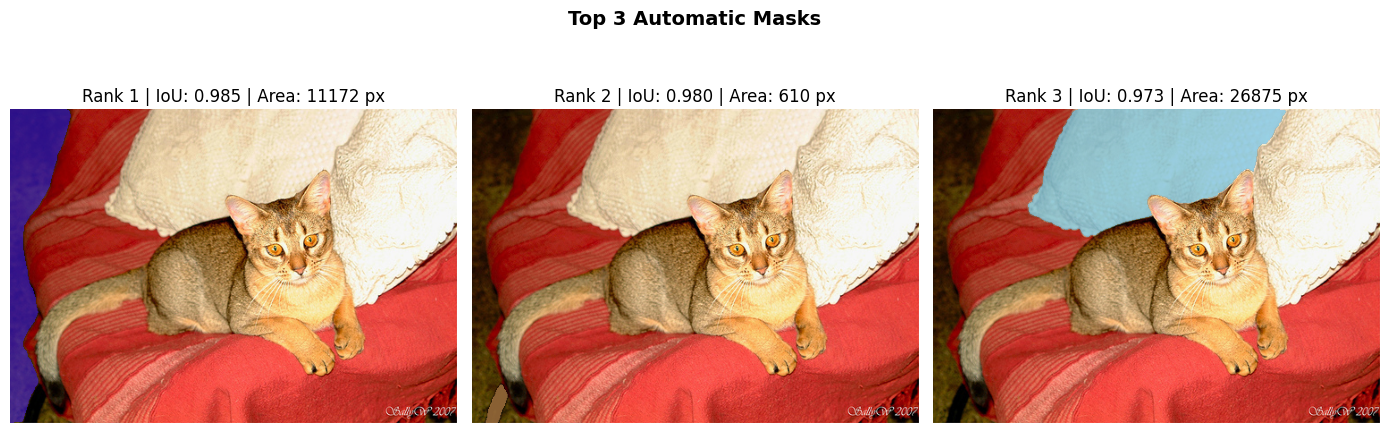

In [72]:
# ── TODO 18 ─────────────────────────────────────────────────────────────────
# 1. Print total number of masks found
# 2. Sort auto_masks by 'predicted_iou' descending
# 3. Display top 3 masks individually (3 columns)
#    Each subplot: original image + one mask overlay
#    Title: f"Rank {i+1} | IoU: {m['predicted_iou']:.3f} | Area: {m['area']} px"

# raise NotImplementedError("TODO 18: sort and display top 3 masks")
# ────────────────────────────────────────────────────────────────────────────
print(f"Total masks found: {len(auto_masks)}")
sorted_masks = sorted(auto_masks, key=lambda m: m['predicted_iou'], reverse=True)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Top 3 Automatic Masks", fontsize=14, fontweight='bold')
for i in range(3):
    mask = sorted_masks[i]
    color = np.random.rand(3)
    axes[i].imshow(auto_img)
    show_mask(mask['segmentation'], axes[i], color=color, alpha=0.6)
    axes[i].set_title(f"Rank {i+1} | IoU: {mask['predicted_iou']:.3f} | Area: {mask['area']} px")
    axes[i].axis('off')
plt.tight_layout()                

### ✍️ Reflection — Automatic Generation
**Q: SAM found N masks automatically. Are all of them meaningful?  
What determines whether a region gets its own mask?**

Not all masks are meaningful.. some cover background textures or partial objects. A region gets its own mask if it scores above the predicted IoU and stability thresholds set in the generator config, and if its area exceeds the minimum region sizee

---
## Part 4 — Metrics: Measuring What We See

You have seen IoU and DICE in the lecture. Now implement them from scratch  
and use them to rigorously compare all three segmentation approaches.

Recall:
$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

$$\text{DICE}(A, B) = \frac{2|A \cap B|}{|A| + |B|}$$


### TODO 19 — Implement IoU from scratch


In [73]:
def compute_iou(pred_mask, gt_mask):
    """
    Compute Intersection over Union between two binary masks.
    Args:
        pred_mask: numpy array (H, W) with values 0 and 1
        gt_mask  : numpy array (H, W) with values 0 and 1
    Returns:
        float in [0, 1]
    """
    # ── TODO 19 ─────────────────────────────────────────────────────────────

    # raise NotImplementedError("TODO 19: implement compute_iou")
    # ────────────────────────────────────────────────────────────────────────
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    iou = intersection / union if union > 0 else 0.0
    return iou

#  checks
perfect = np.array([[1, 1, 0], [0, 1, 0]])
assert compute_iou(perfect, perfect) == 1.0, "Perfect overlap should give IoU=1"
empty   = np.zeros_like(perfect)
assert compute_iou(perfect, empty)   == 0.0, "No overlap should give IoU=0"
print("✅ IoU sanity checks passed")


✅ IoU sanity checks passed


### TODO 20 — Implement DICE from scratch


In [74]:
def compute_dice(pred_mask, gt_mask):
    """
    Compute DICE score between two binary masks.
    Args:
        pred_mask: numpy array (H, W) with values 0 and 1
        gt_mask  : numpy array (H, W) with values 0 and 1
    Returns:
        float in [0, 1]
    """
    # ── TODO 20 ─────────────────────────────────────────────────────────────

    # raise NotImplementedError("TODO 20: implement compute_dice")
    # ────────────────────────────────────────────────────────────────────────
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    pred_sum = pred_mask.sum()
    gt_sum = gt_mask.sum()
    dice = (2 * intersection) / (pred_sum + gt_sum) if (pred_sum + gt_sum) > 0 else 0.0
    return dice

#  checks
assert compute_dice(perfect, perfect) == 1.0, "Perfect overlap should give DICE=1"
assert compute_dice(perfect, empty)   == 0.0, "No overlap should give DICE=0"
print("✅ DICE sanity checks passed")


✅ DICE sanity checks passed


### TODO 21 — Evaluate all three methods on 50 images
Compute mean IoU and mean DICE for:
- Color thresholding
- SAM point prompt (center point)
- SAM box prompt (from ground truth bbox)


In [75]:
def evaluate_method(dataset, predictor, method="color", n=50):
    """
    Evaluate a segmentation method on n images.
    Returns dict with 'iou' and 'dice' lists.
    """
    ious, dices = [], []
    print(f"Evaluating: {method} on {n} images ...")

    for img_path, mask_path in dataset[:n]:
        img = load_image(img_path)
        gt  = trimap_to_binary(load_mask(mask_path))

        if method == "color":
            pred = morphological_clean(color_threshold_segment(img))

        elif method == "otsu":
            pred = morphological_clean(otsu_segment(img))

        elif method == "sam_point":
            # ── TODO 21a ────────────────────────────────────────────────────

            # raise NotImplementedError("TODO 21a: SAM point prediction")
            # ────────────────────────────────────────────────────────────────
            predictor.set_image(img)
            height, width = img.shape[0], img.shape[1]
            point_coords = np.array([[width//2, height//2]])
            point_labels = np.array([1])
            res = predictor.predict(point_coords=point_coords, point_labels=point_labels, multimask_output=True)
            best_idx = np.argmax(res[1])  # scores are in res[1]
            pred = res[0][best_idx]

        elif method == "sam_box":
            # ── TODO 21b ────────────────────────────────────────────────────

            # raise NotImplementedError("TODO 21b: SAM box prediction")
            # ────────────────────────────────────────────────────────────────
            predictor.set_image(img)
            box = mask_to_bbox(gt)
            res = predictor.predict(box=box[None, :], multimask_output=False)
            pred = res[0][0]

        # Resize pred to gt size if needed
        if pred.shape != gt.shape:
            pred = cv2.resize(pred.astype(np.uint8), (gt.shape[1], gt.shape[0]))

        ious.append(compute_iou(pred.astype(bool), gt.astype(bool)))
        dices.append(compute_dice(pred.astype(bool), gt.astype(bool)))

    return {"iou": ious, "dice": dices}

# ── TODO 21c ─────────────────────────────────────────────────────────────────
# Run evaluate_method for all 4 methods and store results in a dict:
# results = {
#     "Color Threshold" : evaluate_method(dataset, predictor, method="color"),
#     "Otsu"            : evaluate_method(dataset, predictor, method="otsu"),
#     "SAM Point"       : evaluate_method(dataset, predictor, method="sam_point"),
#     "SAM Box"         : evaluate_method(dataset, predictor, method="sam_box"),
# }
# raise NotImplementedError("TODO 21c: run all evaluations")
# ─────────────────────────────────────────────────────────────────────────────
methods = ["color", "otsu", "sam_point", "sam_box"]
results = {}
for method in methods:
    if method == "color":
        name = "Color Threshold"
    elif method == "otsu":
        name = "Otsu"
    elif method == "sam_point":
        name = "SAM Point"
    elif method == "sam_box":
        name = "SAM Box"
    results[name] = evaluate_method(dataset, predictor, method=method)

Evaluating: color on 50 images ...
Evaluating: otsu on 50 images ...
Evaluating: sam_point on 50 images ...
Evaluating: sam_box on 50 images ...


In [76]:
# ── Print results table (given — run after TODO 21) ─────────────────────────
print("\n" + "="*55)
print(f"{'Method':<20} {'Mean IoU':>10} {'Mean DICE':>10}")
print("="*55)
for method_name, res in results.items():
    print(f"{method_name:<20} {np.mean(res['iou']):>10.3f} {np.mean(res['dice']):>10.3f}")
print("="*55)



Method                 Mean IoU  Mean DICE
Color Threshold           0.308      0.437
Otsu                      0.132      0.218
SAM Point                 0.556      0.635
SAM Box                   0.740      0.831


### TODO 22 — Plot results
Two plots:
1. **Bar chart** comparing mean IoU across all methods
2. **Scatter plot** of per-image IoU: SAM point vs SAM box (one dot per image)


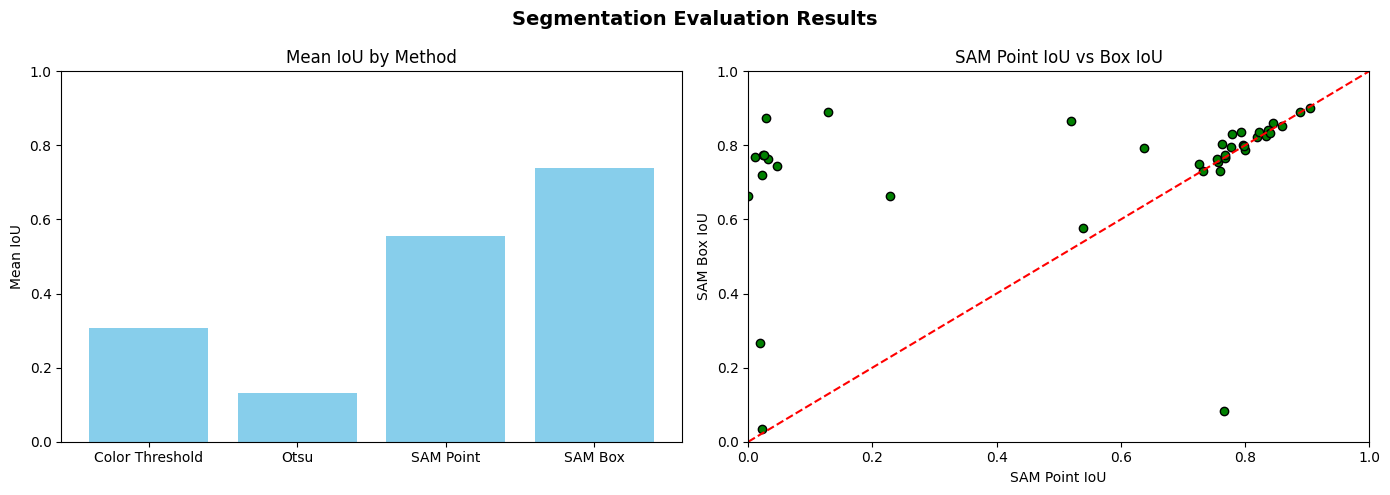

In [78]:
def plot_results(results):
    """
    Plot 1: bar chart of mean IoU per method
    Plot 2: scatter plot SAM point vs SAM box per image
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Segmentation Evaluation Results", fontsize=14, fontweight='bold')

    # ── TODO 22a — Bar chart ─────────────────────────────────────────────────

    # raise NotImplementedError("TODO 22a: bar chart")
    # ────────────────────────────────────────────────────────────────────────
    method_names = list(results.keys())
    mean_ious = [np.mean(results[m]['iou']) for m in method_names]
    axes[0].bar(method_names, mean_ious, color='skyblue')
    axes[0].set_title("Mean IoU by Method")
    axes[0].set_ylabel("Mean IoU")
    axes[0].set_ylim(0, 1)

    # ── TODO 22b — Scatter plot ──────────────────────────────────────────────

    # raise NotImplementedError("TODO 22b: scatter plot")
    # ────────────────────────────────────────────────────────────────────────
    sam_point_ious = results["SAM Point"]['iou']
    sam_box_ious = results["SAM Box"]['iou']
    axes[1].scatter(sam_point_ious, sam_box_ious, color='green', edgecolors='black')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--')  # y=x line
    axes[1].set_title("SAM Point IoU vs Box IoU")
    axes[1].set_xlabel("SAM Point IoU")
    axes[1].set_ylabel("SAM Box IoU")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

plot_results(results)


### TODO 23 — Failure analysis
Find the 3 images where SAM box prompt got the **lowest IoU**.  
Display each with: original image | SAM box mask | ground truth | IoU score as title.  
Write 3 sentences below explaining what went wrong visually.


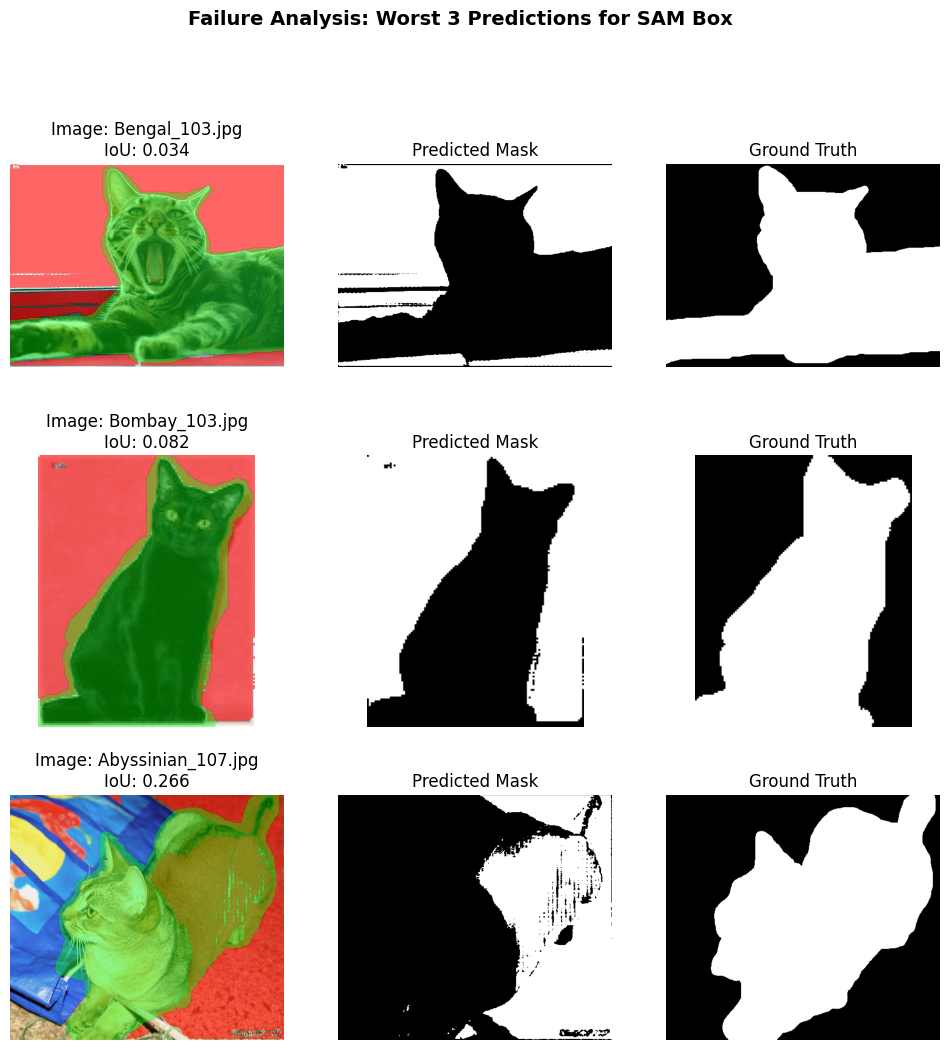

In [79]:
def failure_analysis(dataset, predictor, results, method_key="SAM Box", n_failures=3):
    """
    Find n worst predictions and display them.
    """
    # ── TODO 23 ─────────────────────────────────────────────────────────────

    # raise NotImplementedError("TODO 23: implement failure_analysis")
    # ────────────────────────────────────────────────────────────────────────
    ious = results[method_key]['iou']
    sorted_indices = np.argsort(ious)  # ascending order
    worst_indices = sorted_indices[:n_failures]
    axes = []
    fig, axes = plt.subplots(n_failures, 3, figsize=(12, 4 * n_failures))
    fig.suptitle(f"Failure Analysis: Worst {n_failures} Predictions for {method_key}", fontsize=14, fontweight='bold')
    for i, idx in enumerate(worst_indices):
        img_path, mask_path = dataset[idx]
        img = load_image(img_path)
        gt = trimap_to_binary(load_mask(mask_path))
        
        predictor.set_image(img)
        box = mask_to_bbox(gt)
        res = predictor.predict(box=box[None, :], multimask_output=False)
        pred_mask = res[0][0]
        
        axes[i, 0].imshow(img)
        show_mask(pred_mask, axes[i, 0], color=[1, 0, 0], alpha=0.6)  # red for prediction
        show_mask(gt, axes[i, 0], color=[0, 1, 0], alpha=0.4)       # green for GT
        axes[i, 0].set_title(f"Image: {img_path.name}\nIoU: {ious[idx]:.3f}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(pred_mask, cmap='gray')
        axes[i, 1].set_title("Predicted Mask")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(gt, cmap='gray')
        axes[i, 2].set_title("Ground Truth")
        axes[i, 2].axis('off')

failure_analysis(dataset, predictor, results)


### ✍️ Failure Analysis — Written Response
**Look at the 3 failure cases above. Write 3 sentences explaining what went wrong and why.**

The bounding box derived from the ground truth mask was still not tight enough to prevent SAM from including background regions that share similar texture with the pet. In some cases the pet blends into the background making it hard for SAM to find a clean boundary even with a box prompt. These failures show that SAM box prompts depend heavily on the quality of the bounding box and struggle when foreground and background have low contrast